# 04b - Noisy-Trained Latent OOD Evaluation

Train one 2D latent autoencoder plus latent propagator using only noisy networks, then evaluate it on 60 networks from each dataset: Reid, dePablo, noisy holdout, and mixed-temperature dePablo. The plots color every held-out point by dataset so in-distribution and out-of-distribution behavior are visible.


## Setup


In [10]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.data import load_dataset, simulation_temperature
from lss.latent.experiment import (
    evaluate_rollout_horizons,
    find_project_root,
    ground_truth_p_ratio,
    prepare_source_spec,
    resolve_existing_path,
    result_tables,
    rollout_steps_for_sims,
    save_result_tables,
    seed_everything,
    train_latent_experiment,
)
from lss.latent.simulation import pearson_r, r2_score
from lss.latent.training import encode_frame_latent
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 120
try:
    display
except NameError:
    def display(obj):
        print(obj)

DATASET_COLORS = {
    'noizy': 'tab:blue',
    'reid': 'tab:orange',
    'depablo': 'tab:green',
    'depablo-10k-mix-temp': 'tab:red',
}


## Configuration

The model is trained only on 40 noisy networks and validated on 20 separate noisy networks from the same dataset. The OOD evaluation samples 60 networks per dataset. For noisy, those 60 come from the held-out noisy test split, so they do not overlap the 40 training or 20 validation networks.


In [11]:
project_root = find_project_root()
seed = random.SystemRandom().randrange(1, 2**31)
seed_everything(seed)
print('run seed:', seed)

train_dataset = 'noizy'
eval_count_per_dataset = 50
rollout_scatter_step = 150
force_train = True

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
    },
    'depablo': {
        'label': 'dePablo',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo mixed temp',
        'path': 'data/depablo-10k-mix-temp.pt',
    },
    'noizy': {
        'label': 'Noisy rand OOL',
        'path_candidates': [
            '../../data/200_rand_pruned_OOL_bidirect_val1057.pt',
            'data/200_rand_pruned_OOL_bidirect_val1057.pt',
            '200_rand_pruned_OOL_bidirect_val1057.pt',
        ],
        'train_count': 80,
        'val_count': 20,
    },
}

cfg = {
    'dataset_name': train_dataset,
    'split_seed': seed,
    'split_stratify_temperature': False,
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    'train_frame_start_order': 0,
    'latent_dim': 2,
    'latent_tokens': 16,
    'hidden_size': 64,
    'edge_feature_dim': 8,
    'ae_max_train_frames_per_sim': 80,
    'dyn_max_train_transitions_per_sim': 80,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    'ae_coordinate_weights': [1.0, 2.0],
    'ae_max_epochs': 220,
    'ae_patience': 6,
    'ae_lr': 1e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 220,
    'dyn_patience': 6,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_objective': 'one_step',
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    'propagator_step_stride': 1,
    'initial_velocity': 'zero',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [10, 20, 50, 100, 150, 300],
    'temperature_pratio_window': 'full',
    'output_root': str(project_root / 'notebooks' / 'results' / 'noisy_train_ood_eval'),
}

device = resolve_device(cfg['device'])
source_spec = prepare_source_spec(train_dataset, dataset_specs, cfg, seed=seed)
run_dir = Path(cfg['output_root']) / train_dataset
run_dir.mkdir(parents=True, exist_ok=True)
print('train dataset:', train_dataset)
print('train path:', source_spec['path'])
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([source_spec]))


run seed: 1976864390
train dataset: noizy
train path: /home/alexz/Documents/course_project/data/200_rand_pruned_OOL_bidirect_val1057.pt
device: cuda
output: /home/alexz/Documents/course_project/notebooks/results/noisy_train_ood_eval/noizy


,label,train_count,val_count,path,source_name,dataset_name,target_mode,ae_target_mode,node_feature_mode,latent_dim,...,ae_max_train_frames_per_sim,dyn_max_train_transitions_per_sim,ae_max_epochs,ae_patience,ae_lr,ae_weight_decay,dyn_max_epochs,dyn_patience,dyn_lr,dyn_weight_decay
0,Noisy rand OOL CV2 delta,80,20,/home/alexz/Documents/course_project/data/200_...,Noisy rand OOL,noizy,delta,delta,delta,2,...,80,80,220,6,0.0001,0.00001,220,6,0.0001,0.00001


## Train Noisy 2D Latent Model


In [ ]:
seed_everything(source_spec['model_seed'])
result = train_latent_experiment(source_spec, cfg, device=device)
results = [result]

tables = result_tables(results)
save_result_tables(tables, run_dir)
print('trained on noisy networks:', len(result['train_data']))
print('noisy val networks:', len(result['val_data']))
print('noisy test networks:', len(result['test_data']))
display(result['rollout_stats'].round(4))



=== Noisy rand OOL CV2 delta ===
                              source                                                                              path  total  train  val  test
200_rand_pruned_OOL_bidirect_val1057 /home/alexz/Documents/course_project/data/200_rand_pruned_OOL_bidirect_val1057.pt    200     80   20   100
autoencoder
ae 0001 train=0.747167 val=0.74657 stale=0
ae 0002 train=0.702614 val=0.740099 stale=0
ae 0003 train=0.679671 val=0.709042 stale=0
ae 0004 train=0.663974 val=0.709022 stale=0
ae 0005 train=0.659305 val=0.705572 stale=0
ae 0010 train=0.636499 val=0.730403 stale=5
latent propagator: objective=one_step step_stride=1 train_rows=6400 val_rows=1600


## Build 60-Network Evaluation Sets


In [ ]:
def shuffled_sample(path_like, count, *, seed):
    path = resolve_existing_path(path_like, project_root=project_root)
    sims = load_dataset(path)
    rng = np.random.default_rng(int(seed))
    order = rng.permutation(len(sims))
    return [sims[int(idx)] for idx in order[: int(count)]], path

# Noisy uses the model's own test split to avoid overlap with the 40 training networks.
eval_sets = {
    'noizy': result['test_data'][:eval_count_per_dataset],
}
resolved_paths = {'noizy': source_spec['path']}
for dataset_name in ['reid', 'depablo', 'depablo-10k-mix-temp']:
    spec = dataset_specs[dataset_name]
    candidates = spec.get('path_candidates', [spec.get('path')])
    last_error = None
    for candidate in candidates:
        try:
            eval_sets[dataset_name], resolved_paths[dataset_name] = shuffled_sample(
                candidate,
                eval_count_per_dataset,
                seed=seed + 7919 * (len(eval_sets) + 1),
            )
            break
        except FileNotFoundError as exc:
            last_error = exc
    else:
        raise last_error

eval_info = pd.DataFrame([
    {
        'dataset_name': name,
        'label': dataset_specs[name]['label'],
        'path': resolved_paths[name],
        'networks': len(sims),
        'has_temperature': bool(any(np.isfinite(simulation_temperature(sim)) for sim in sims)),
    }
    for name, sims in eval_sets.items()
])
display(eval_info)


,dataset_name,label,path,networks,has_temperature
0,noizy,Noisy rand OOL,/home/alexz/Documents/course_project/data/200_...,80,False
1,reid,Reid,/home/alexz/Documents/course_project/data/new_...,80,False
2,depablo,dePablo,/home/alexz/Documents/course_project/data/2340...,80,False
3,depablo-10k-mix-temp,dePablo mixed temp,/home/alexz/Documents/course_project/data/depa...,80,True


## Initial Latent Readout Across Datasets

Fit the p-ratio readout on noisy validation networks only, then apply the same readout to all four 60-network evaluation sets.


In [ ]:
def latent_table_for_dataset(result, sims, dataset_name, split_name, *, device):
    rows = []
    params = result['params']
    ae_model = result['ae']
    ae_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            z = encode_frame_latent(
                ae_model,
                sim,
                0,
                pos_dim=int(params['pos_dim']),
                node_feature_mode=params['node_feature_mode'],
                normalizers=result['normalizers'],
                device=device,
            ).detach().cpu().numpy().reshape(-1)
            rows.append({
                'dataset_name': dataset_name,
                'dataset_label': dataset_specs[dataset_name]['label'],
                'split': split_name,
                'sim_idx': int(sim_idx),
                'frames': int(len(sim)),
                'nodes': int(sim[0].x.shape[0]),
                'temperature': simulation_temperature(sim),
                'final_p_ratio': ground_truth_p_ratio(sim, -1, dataset_name=dataset_name),
                **{f'z{idx}': float(value) for idx, value in enumerate(z)},
            })
    return pd.DataFrame(rows)

train_latent_df = latent_table_for_dataset(result, result['val_data'], train_dataset, 'noisy_val_fit', device=device)
ood_latent_df = pd.concat(
    [latent_table_for_dataset(result, sims, name, 'ood_eval', device=device) for name, sims in eval_sets.items()],
    ignore_index=True,
)
z_cols = sorted([col for col in train_latent_df.columns if col.startswith('z')], key=lambda c: int(c[1:]))

X_fit = train_latent_df[z_cols].to_numpy(float)
y_fit = train_latent_df['final_p_ratio'].to_numpy(float)
x_mean = X_fit.mean(axis=0)
x_std = X_fit.std(axis=0) + 1e-12
design_fit = np.column_stack([np.ones(len(X_fit)), (X_fit - x_mean) / x_std])
coef = np.linalg.lstsq(design_fit, y_fit, rcond=None)[0]
X_eval = ood_latent_df[z_cols].to_numpy(float)
design_eval = np.column_stack([np.ones(len(X_eval)), (X_eval - x_mean) / x_std])
ood_latent_df['pred_final_p_ratio_from_initial_z'] = design_eval @ coef

latent_score_rows = []
for dataset_name, group in ood_latent_df.groupby('dataset_name'):
    latent_score_rows.append({
        'dataset_name': dataset_name,
        'dataset_label': group['dataset_label'].iloc[0],
        'n': len(group),
        'initial_z_to_final_p_ratio_r2': r2_score(group['final_p_ratio'], group['pred_final_p_ratio_from_initial_z']),
        'initial_z_to_final_p_ratio_r': pearson_r(group['final_p_ratio'], group['pred_final_p_ratio_from_initial_z']),
    })
latent_score_df = pd.DataFrame(latent_score_rows).sort_values('dataset_name')
ood_latent_df.to_csv(run_dir / 'ood_initial_latent_predictions.csv', index=False)
latent_score_df.to_csv(run_dir / 'ood_initial_latent_scores.csv', index=False)
display(latent_score_df.round(4))


,dataset_name,dataset_label,n,initial_z_to_final_p_ratio_r2,initial_z_to_final_p_ratio_r
0,depablo,dePablo,80,-0.1052,0.0518
1,depablo-10k-mix-temp,dePablo mixed temp,80,-0.0627,0.1766
2,noizy,Noisy rand OOL,80,0.0063,0.1948
3,reid,Reid,80,-1.3438,0.8531


## Scatter: Initial Latent Readout Colored By Dataset


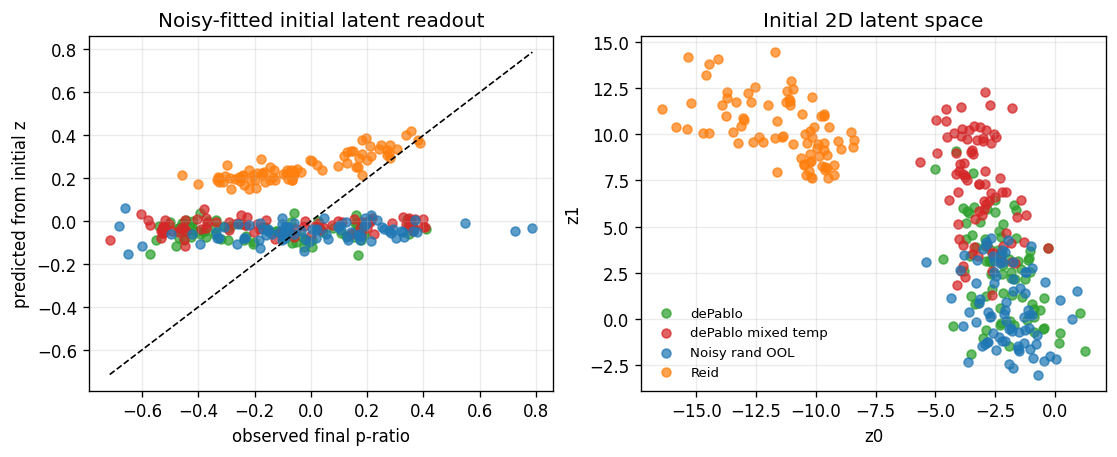

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7), constrained_layout=True)
for dataset_name, group in ood_latent_df.groupby('dataset_name'):
    label = group['dataset_label'].iloc[0]
    color = DATASET_COLORS.get(dataset_name)
    axes[0].scatter(
        group['final_p_ratio'],
        group['pred_final_p_ratio_from_initial_z'],
        s=28,
        alpha=0.72,
        color=color,
        label=label,
    )
    axes[1].scatter(group['z0'], group['z1'], s=28, alpha=0.72, color=color, label=label)
lo = min(ood_latent_df['final_p_ratio'].min(), ood_latent_df['pred_final_p_ratio_from_initial_z'].min())
hi = max(ood_latent_df['final_p_ratio'].max(), ood_latent_df['pred_final_p_ratio_from_initial_z'].max())
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set(
    title='Noisy-fitted initial latent readout',
    xlabel='observed final p-ratio',
    ylabel='predicted from initial z',
)
axes[1].set(title='Initial 2D latent space', xlabel='z0', ylabel='z1')
for ax in axes:
    ax.grid(alpha=0.25)
axes[1].legend(frameon=False, fontsize=8)
plt.show()


## Rollout Evaluation Across Datasets

The same noisy-trained AE and propagator are rolled forward on each dataset. For mixed-temperature dePablo, the p-ratio calculation uses the trajectory-style estimator; the others use the endpoint rollout estimator.


In [ ]:
rollout_parts = []
rollout_stats_parts = []
for dataset_name, sims in eval_sets.items():
    local_cfg = {**result['params'], 'dataset_name': dataset_name}
    steps = rollout_steps_for_sims(
        sims,
        cfg['rollout_steps_grid'],
        frame_skip=int(local_cfg.get('frame_skip', 1)),
    )
    rows, stats = evaluate_rollout_horizons(
        result['ae'],
        result['dyn'],
        sims,
        result['latent_stats'],
        cfg=local_cfg,
        normalizers=result['normalizers'],
        dataset=dataset_specs[dataset_name]['label'],
        split_name='ood_eval',
        rollout_steps=steps,
        device=device,
    )
    rows = rows.assign(dataset_name=dataset_name, dataset_label=dataset_specs[dataset_name]['label'])
    stats = stats.assign(dataset_name=dataset_name, dataset_label=dataset_specs[dataset_name]['label'])
    rollout_parts.append(rows)
    rollout_stats_parts.append(stats)

ood_rollout_df = pd.concat(rollout_parts, ignore_index=True) if rollout_parts else pd.DataFrame()
ood_rollout_stats_df = pd.concat(rollout_stats_parts, ignore_index=True) if rollout_stats_parts else pd.DataFrame()
ood_rollout_df.to_csv(run_dir / 'ood_rollout_predictions.csv', index=False)
ood_rollout_stats_df.to_csv(run_dir / 'ood_rollout_scores.csv', index=False)
display(ood_rollout_stats_df.sort_values(['dataset_name', 'rollout_steps']).round(4))


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,dataset_name,dataset_label
12,dePablo,ood_eval,10,80,-2.8456,-0.2282,0.1745,0.0000,0.0000,0.0000,3.1737,1.5146,0.0000,depablo,dePablo
13,dePablo,ood_eval,20,80,-4.1559,-0.4672,0.3012,0.0000,0.0000,0.0000,1.9854,0.9650,0.0350,depablo,dePablo
14,dePablo,ood_eval,50,80,-8.9003,-0.7986,0.6965,0.0001,0.0001,0.0001,1.2281,0.9332,0.0668,depablo,dePablo
15,dePablo,ood_eval,100,80,-9.0950,-0.5270,0.7699,0.0006,0.0005,0.0005,0.9904,1.2682,0.0000,depablo,dePablo
16,dePablo,ood_eval,110,80,-8.3360,-0.4225,0.7186,0.0008,0.0006,0.0006,0.9940,1.3474,0.0000,depablo,dePablo
17,dePablo mixed temp,ood_eval,10,80,-0.9652,-0.0257,0.4344,0.0010,0.0010,0.0000,0.0255,0.9858,0.0142,depablo-10k-mix-temp,dePablo mixed temp
18,dePablo mixed temp,ood_eval,20,80,-1.8183,0.0808,0.5442,0.0011,0.0011,0.0001,0.0732,0.9601,0.0399,depablo-10k-mix-temp,dePablo mixed temp
19,dePablo mixed temp,ood_eval,50,80,-7.2753,0.3127,0.9685,0.0017,0.0017,0.0004,0.2247,0.9672,0.0328,depablo-10k-mix-temp,dePablo mixed temp
20,dePablo mixed temp,ood_eval,100,80,-3.9214,0.6899,0.4733,0.0048,0.0039,0.0018,0.4560,1.2254,0.0000,depablo-10k-mix-temp,dePablo mixed temp
21,dePablo mixed temp,ood_eval,150,80,-1.6581,0.5958,0.2714,0.0121,0.0074,0.0059,0.7967,1.6310,0.0000,depablo-10k-mix-temp,dePablo mixed temp


## Scatter: Rollout P-Ratio Colored By Dataset


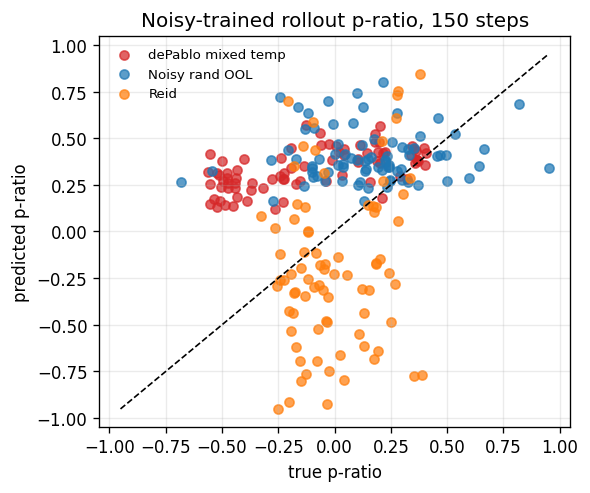

In [ ]:
available_steps = np.sort(ood_rollout_df['rollout_steps'].dropna().unique().astype(int))
plot_step = int(available_steps[np.argmin(np.abs(available_steps - rollout_scatter_step))])
scatter_df = ood_rollout_df[ood_rollout_df['rollout_steps'].eq(plot_step)].copy()

fig, ax = plt.subplots(figsize=(4.8, 4.0), constrained_layout=True)
for dataset_name, group in scatter_df.groupby('dataset_name'):
    ax.scatter(
        group['true_p_ratio'],
        group['pred_p_ratio'],
        s=30,
        alpha=0.72,
        color=DATASET_COLORS.get(dataset_name),
        label=group['dataset_label'].iloc[0],
    )
lo = min(scatter_df['true_p_ratio'].min(), scatter_df['pred_p_ratio'].min())
hi = max(scatter_df['true_p_ratio'].max(), scatter_df['pred_p_ratio'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set(
    title=f'Noisy-trained rollout p-ratio, {plot_step} steps',
    xlabel='true p-ratio',
    ylabel='predicted p-ratio',
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.show()


## Rollout R2 By Horizon And Dataset


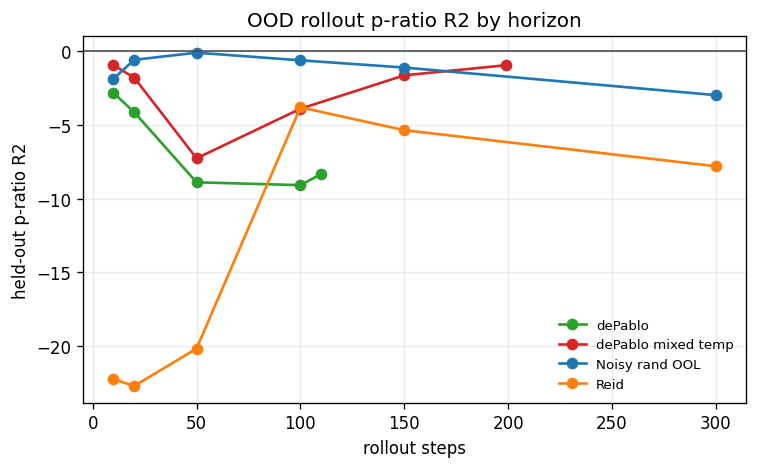

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.8), constrained_layout=True)
for dataset_name, group in ood_rollout_stats_df.sort_values('rollout_steps').groupby('dataset_name'):
    ax.plot(
        group['rollout_steps'],
        group['p_ratio_r2'],
        marker='o',
        lw=1.6,
        color=DATASET_COLORS.get(dataset_name),
        label=group['dataset_label'].iloc[0],
    )
ax.axhline(0, color='0.3', lw=1)
ax.set(
    title='OOD rollout p-ratio R2 by horizon',
    xlabel='rollout steps',
    ylabel='held-out p-ratio R2',
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.show()
